# Heart Disease Prediction
# Phase 3 — Filter Feature Selection
### UCI Cleveland Heart Disease Dataset

---

**Continues from:** `03_preprocessing.py`

**What is Filter Feature Selection?**

Filter methods select the most important features using only statistical measures, before any machine learning model is trained.

Unlike Wrapper methods (which repeatedly train models to test different feature subsets) or Embedded methods (which select features during model training), Filter methods are fast because they evaluate each feature independently.

Think of it like this:
- 🔵 **Filter** = use statistics to judge each feature before training starts
- 🟡 **Wrapper** = try many different combinations and see which works best
- 🟢 **Embedded** = let the model itself decide which features matter while training

**Filter methods used in this notebook:**
1. **Variance Threshold** — removes features with almost no variation
2. **Chi-Square Test** — measures how strongly each feature relates to the target
3. **ANOVA F-Test** — checks whether feature values differ between classes
4. **Pearson Correlation** — measures linear relationship with the target
5. **Mutual Information** — measures how much information a feature gives about the target
6. **SelectKBest** — keeps only the top K highest-scoring features

**Goal:** Combine all filter methods → vote for the best features → retrain all 8 models → compare with Baseline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import (
    VarianceThreshold,
    chi2,
    f_classif,
    mutual_info_classif,
    SelectKBest
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
## Cell 1 — Install & Import Libraries

> We import all libraries needed for data loading, feature selection, visualization, saving results, and retraining the models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import (
    VarianceThreshold,
    chi2,
    f_classif,
    mutual_info_classif,
    SelectKBest
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
## Cell 2 — Load Preprocessed Data

> We load the same preprocessed training and testing data created in `03_preprocessing.py`.

> Both scaled and unscaled versions are needed because some filter methods work better with scaled data, while others require the original values.

In [3]:
# ============================================================
# CELL 2 — Load Preprocessed Data from saved_data/
# ============================================================

LOAD_DIR = 'saved_data'

# Scaled versions → used for ANOVA, Pearson, Mutual Info
X_train_scaled = joblib.load(f'{LOAD_DIR}/X_train_scaled.pkl')
X_test_scaled  = joblib.load(f'{LOAD_DIR}/X_test_scaled.pkl')

# Raw (unscaled) versions → used for Chi-Square
X_train_raw    = joblib.load(f'{LOAD_DIR}/X_train_raw.pkl')
X_test_raw     = joblib.load(f'{LOAD_DIR}/X_test_raw.pkl')

# Labels
y_train        = joblib.load(f'{LOAD_DIR}/y_train.pkl')
y_test         = joblib.load(f'{LOAD_DIR}/y_test.pkl')

# Feature names
feature_names  = joblib.load(f'{LOAD_DIR}/feature_names.pkl')

# Baseline results
baseline_results = joblib.load(f'{LOAD_DIR}/baseline_results.pkl')

# --- Convert to proper pandas objects ---
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names) if not isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names) if not isinstance(X_test_scaled,  pd.DataFrame) else X_test_scaled
X_train_raw    = pd.DataFrame(X_train_raw,    columns=feature_names) if not isinstance(X_train_raw,    pd.DataFrame) else X_train_raw
X_test_raw     = pd.DataFrame(X_test_raw,     columns=feature_names) if not isinstance(X_test_raw,     pd.DataFrame) else X_test_raw
y_train        = pd.Series(y_train) if not isinstance(y_train, pd.Series) else y_train
y_test         = pd.Series(y_test)  if not isinstance(y_test,  pd.Series) else y_test

# --- Reset indices ---
for df in [X_train_scaled, X_test_scaled, X_train_raw, X_test_raw]:
    df.reset_index(drop=True, inplace=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# --- Combine train+test for filter scoring ---
X_full_scaled = pd.concat([X_train_scaled, X_test_scaled], axis=0).reset_index(drop=True)
X_full_raw    = pd.concat([X_train_raw,    X_test_raw],    axis=0).reset_index(drop=True)
y_full        = pd.concat([y_train,        y_test],        axis=0).reset_index(drop=True)

print('✅ Data loaded successfully!')
print(f'   X_train_scaled : {X_train_scaled.shape}')
print(f'   X_test_scaled  : {X_test_scaled.shape}')
print(f'   X_train_raw    : {X_train_raw.shape}')
print(f'   X_test_raw     : {X_test_raw.shape}')
print(f'   X_full_scaled  : {X_full_scaled.shape}')
print(f'   y_train classes: {y_train.value_counts().to_dict()}')
print(f'   y_test  classes: {y_test.value_counts().to_dict()}')
print(f'   Total features : {len(feature_names)}')
print(f'   Feature names  : {feature_names}')

✅ Data loaded successfully!
   X_train_scaled : (262, 22)
   X_test_scaled  : (61, 22)
   X_train_raw    : (262, 22)
   X_test_raw     : (61, 22)
   X_full_scaled  : (323, 22)
   y_train classes: {1: 131, 0: 131}
   y_test  classes: {0: 33, 1: 28}
   Total features : 22
   Feature names  : ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_4', 'thal_5', 'thal_6', 'thal_7', 'ca_1', 'ca_2', 'ca_3']


---
## Cell 3 — Method 1: Variance Threshold

### What is Variance Threshold?

Variance Threshold removes features that have very little variation across all samples.

If a feature almost always has the same value, it usually does not help the model make decisions.

For example:
- A feature that is `0` for almost every patient provides very little information
- A feature with larger variation is more likely to separate healthy and sick patients

**How it works:**
- Calculate the variance of every feature
- Compare it to a minimum threshold
- Remove any feature whose variance is below that threshold

In this notebook, we use:

`threshold = 0.01`

So:
- Variance < 0.01 → remove feature
- Variance ≥ 0.01 → keep feature

**Why is this useful?**

It is the fastest feature selection method and helps remove clearly useless features before using more advanced methods.

📊 METHOD 1: VARIANCE THRESHOLD
   Total features   : 22
   Features REMOVED : 2
   Features KEPT    : 20
   Removed          : ['thal_4', 'thal_5']


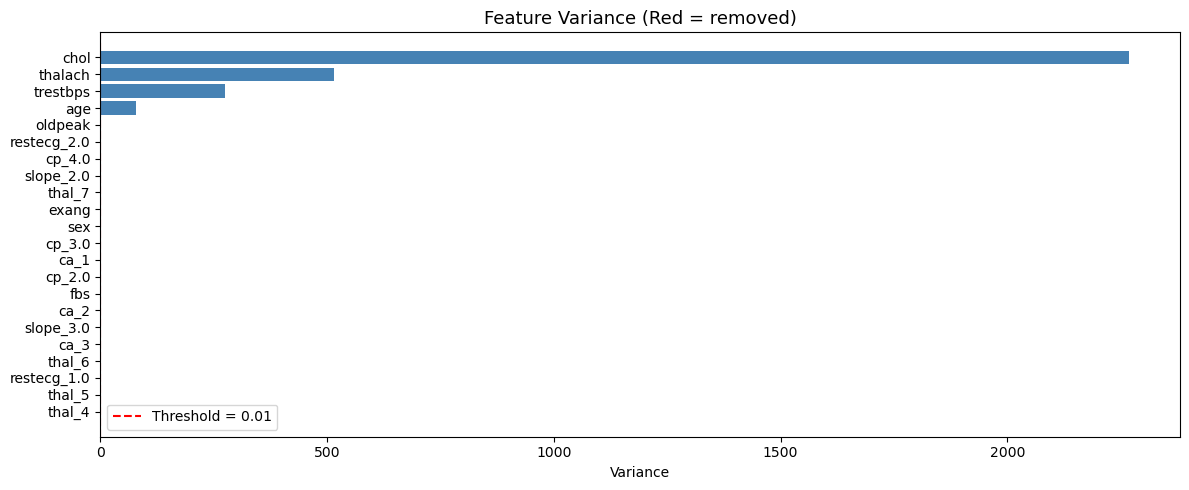


✅ Working shape after variance filter: (323, 20)


In [4]:
# ================================================================
# METHOD 1: VARIANCE THRESHOLD
# ================================================================
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_full_raw)

variance_mask         = selector_var.get_support()
low_variance_features = X_full_raw.columns[~variance_mask].tolist()
kept_after_variance   = X_full_raw.columns[variance_mask].tolist()

print("=" * 55)
print("📊 METHOD 1: VARIANCE THRESHOLD")
print("=" * 55)
print(f"   Total features   : {X_full_raw.shape[1]}")
print(f"   Features REMOVED : {len(low_variance_features)}")
print(f"   Features KEPT    : {len(kept_after_variance)}")
print(f"   Removed          : {low_variance_features}")

variances = X_full_raw.var().sort_values()
plt.figure(figsize=(12, 5))
colors = ['red' if v < 0.01 else 'steelblue' for v in variances]
plt.barh(variances.index, variances.values, color=colors)
plt.axvline(x=0.01, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.01')
plt.title('Feature Variance (Red = removed)', fontsize=13)
plt.xlabel('Variance')
plt.legend()
plt.tight_layout()
plt.show()

X_work_scaled = X_full_scaled[kept_after_variance].copy()
X_work_raw    = X_full_raw[kept_after_variance].copy()
print(f"\n✅ Working shape after variance filter: {X_work_scaled.shape}")

---
## Cell 4 — Method 2: Chi-Square Test

### What is the Chi-Square Test?

The Chi-Square test measures how strongly each feature is related to the target class.

A high Chi-Square score means the feature changes a lot between patients with and without heart disease.

**How it works:**
- Compare the distribution of each feature across the target classes
- Features that are more different between the classes receive higher scores

The test also returns a `p-value`:
- Small p-value (< 0.05) → feature is statistically important
- Large p-value (≥ 0.05) → feature is probably not useful

**Important:**  
Chi-Square only works with non-negative values, so we use the raw feature values after clipping negative numbers if needed.

📊 METHOD 2: CHI-SQUARE TEST (Top 15)
  Feature  Chi2_Score      P_Value
  thalach  195.664172 1.845260e-44
  oldpeak   68.715796 1.137263e-16
   cp_4.0   39.905900 2.664970e-10
   thal_7   37.786551 7.892402e-10
    exang   36.698680 1.378728e-09
     chol   29.369670 5.980638e-08
   cp_3.0   27.548989 1.531654e-07
      age   22.616929 1.977346e-06
slope_2.0   21.515847 3.509168e-06
   cp_2.0   19.505943 1.002872e-05
     ca_2   14.288946 1.567828e-04
 trestbps   11.863895 5.723272e-04
     ca_1   11.775837 6.000453e-04
     ca_3   10.240683 1.373767e-03
      sex    6.731290 9.473607e-03

✅ Significant (p < 0.05): 15 / 20


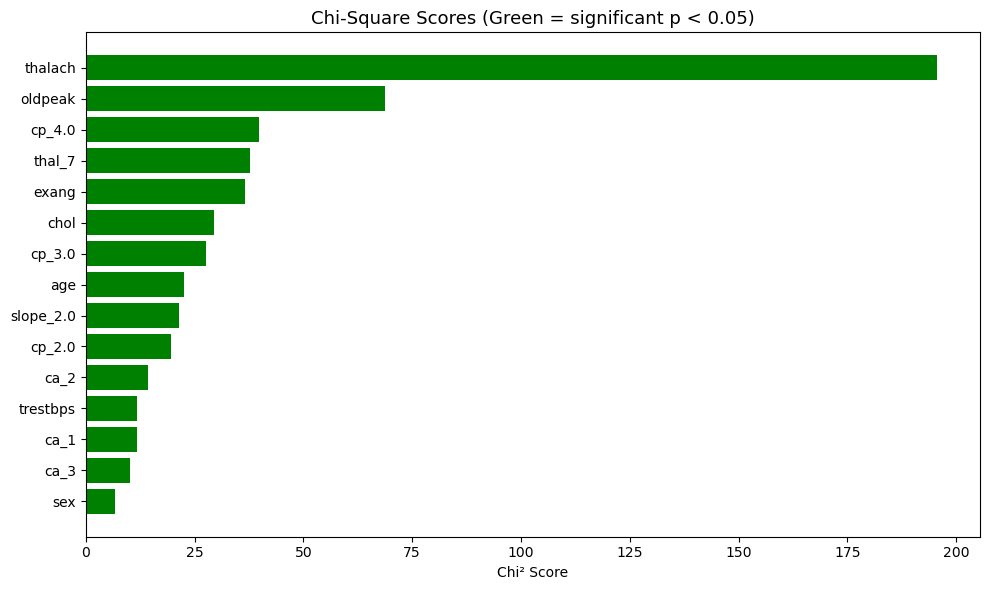

In [5]:
# ================================================================
# METHOD 2: CHI-SQUARE TEST
# ================================================================
X_chi2 = X_work_raw.clip(lower=0)
chi2_scores, chi2_pvalues = chi2(X_chi2, y_full)

chi2_df = pd.DataFrame({
    'Feature'   : X_work_raw.columns,
    'Chi2_Score': chi2_scores,
    'P_Value'   : chi2_pvalues
}).sort_values('Chi2_Score', ascending=False).reset_index(drop=True)

print("=" * 55)
print("📊 METHOD 2: CHI-SQUARE TEST (Top 15)")
print("=" * 55)
print(chi2_df.head(15).to_string(index=False))
print(f"\n✅ Significant (p < 0.05): {len(chi2_df[chi2_df['P_Value'] < 0.05])} / {len(chi2_df)}")

top_chi2 = chi2_df.head(15)
plt.figure(figsize=(10, 6))
colors = ['green' if p < 0.05 else 'salmon' for p in top_chi2['P_Value']]
plt.barh(top_chi2['Feature'][::-1], top_chi2['Chi2_Score'][::-1], color=colors[::-1])
plt.title('Chi-Square Scores (Green = significant p < 0.05)', fontsize=13)
plt.xlabel('Chi² Score')
plt.tight_layout()
plt.show()

---
## Cell 5 — Method 3: ANOVA F-Test

### What is the ANOVA F-Test?

ANOVA (Analysis of Variance) checks whether the average value of a feature is significantly different between the target classes.

For example:
- If people with heart disease usually have much higher cholesterol than people without heart disease,
  then cholesterol will get a high F-score.

**How it works:**
- Compare the average feature value in each class
- Calculate an F-score for every feature
- Larger F-score = stronger difference between classes

The method also gives a `p-value`:
- p-value < 0.05 → feature is significant
- p-value ≥ 0.05 → feature is less useful

Because ANOVA depends on numeric scale, we use the scaled dataset here.

📊 METHOD 3: ANOVA F-TEST (Top 15)
    Feature   F_Score      P_Value
     cp_4.0 99.228344 1.521206e-20
     thal_7 74.316687 3.090394e-16
    oldpeak 72.375217 6.882087e-16
    thalach 68.506444 3.436447e-15
      exang 65.701001 1.114896e-14
  slope_2.0 46.513966 4.528642e-11
     cp_3.0 42.220973 3.108935e-10
     cp_2.0 24.700413 1.091622e-06
        sex 22.214174 3.639338e-06
       ca_2 17.006169 4.750132e-05
        age 16.582045 5.873851e-05
       ca_1 15.801262 8.695374e-05
       ca_3 11.228538 9.015904e-04
restecg_2.0  6.313927 1.246909e-02
   trestbps  5.776171 1.681175e-02

✅ Significant (p < 0.05): 15 / 20


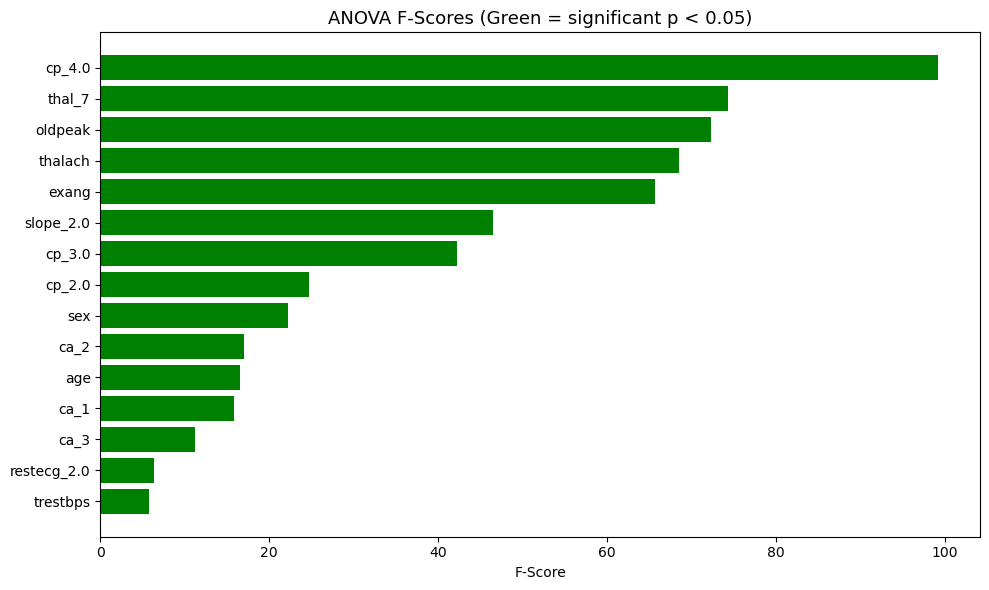

In [6]:
# ================================================================
# METHOD 3: ANOVA F-TEST
# ================================================================
f_scores, f_pvalues = f_classif(X_work_scaled, y_full)

anova_df = pd.DataFrame({
    'Feature': X_work_scaled.columns,
    'F_Score': f_scores,
    'P_Value': f_pvalues
}).sort_values('F_Score', ascending=False).reset_index(drop=True)

print("=" * 55)
print("📊 METHOD 3: ANOVA F-TEST (Top 15)")
print("=" * 55)
print(anova_df.head(15).to_string(index=False))
print(f"\n✅ Significant (p < 0.05): {len(anova_df[anova_df['P_Value'] < 0.05])} / {len(anova_df)}")

top_anova = anova_df.head(15)
plt.figure(figsize=(10, 6))
colors = ['green' if p < 0.05 else 'salmon' for p in top_anova['P_Value']]
plt.barh(top_anova['Feature'][::-1], top_anova['F_Score'][::-1], color=colors[::-1])
plt.title('ANOVA F-Scores (Green = significant p < 0.05)', fontsize=13)
plt.xlabel('F-Score')
plt.tight_layout()
plt.show()

---
## Cell 6 — Method 4: Pearson Correlation

### What is Pearson Correlation?

Pearson Correlation measures the strength of the linear relationship between a feature and the target.

The correlation value ranges from `-1` to `+1`:

- `+1` = strong positive relationship
- `-1` = strong negative relationship
- `0` = no linear relationship

In this notebook, we use the absolute value:

`|correlation|`

because both strong positive and strong negative relationships are useful.

We keep features with:

`|correlation| ≥ 0.1`

Features with very small correlation are likely not useful for prediction.

📊 METHOD 4: PEARSON CORRELATION WITH TARGET
    Feature  Correlation
     cp_4.0     0.485932
     thal_7     0.433581
    oldpeak     0.428935
    thalach     0.419381
      exang     0.412191
  slope_2.0     0.355758
     cp_3.0     0.340941
     cp_2.0     0.267302
        sex     0.254409
       ca_2     0.224306
        age     0.221630
       ca_1     0.216600
       ca_3     0.183841
restecg_2.0     0.138889
   trestbps     0.132952
       chol     0.099413
     thal_6     0.084748
restecg_1.0     0.057730
  slope_3.0     0.041758
        fbs     0.006309


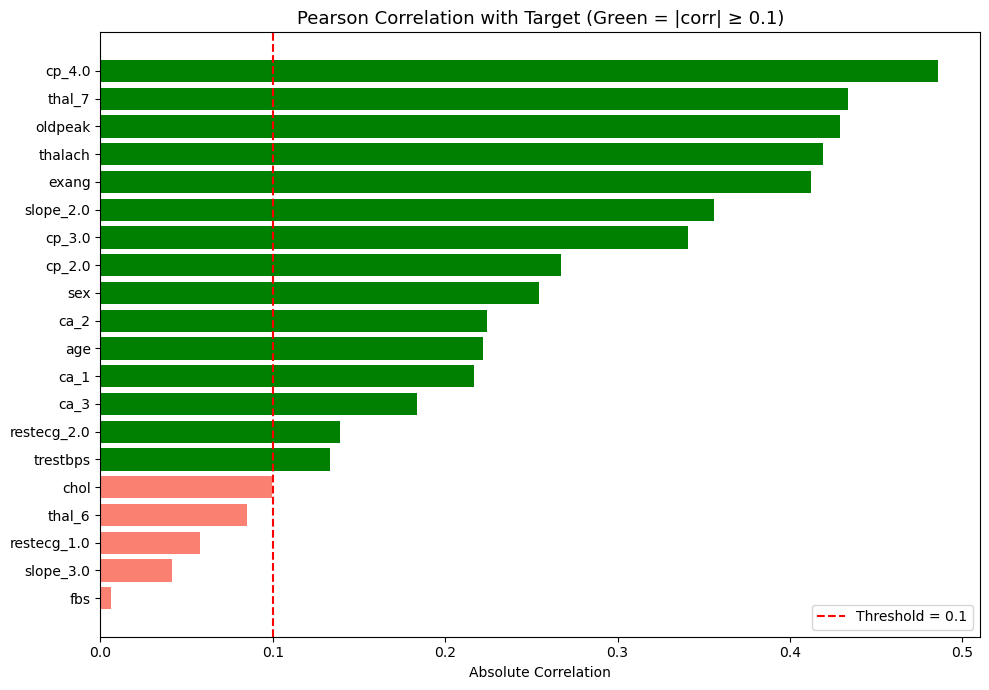

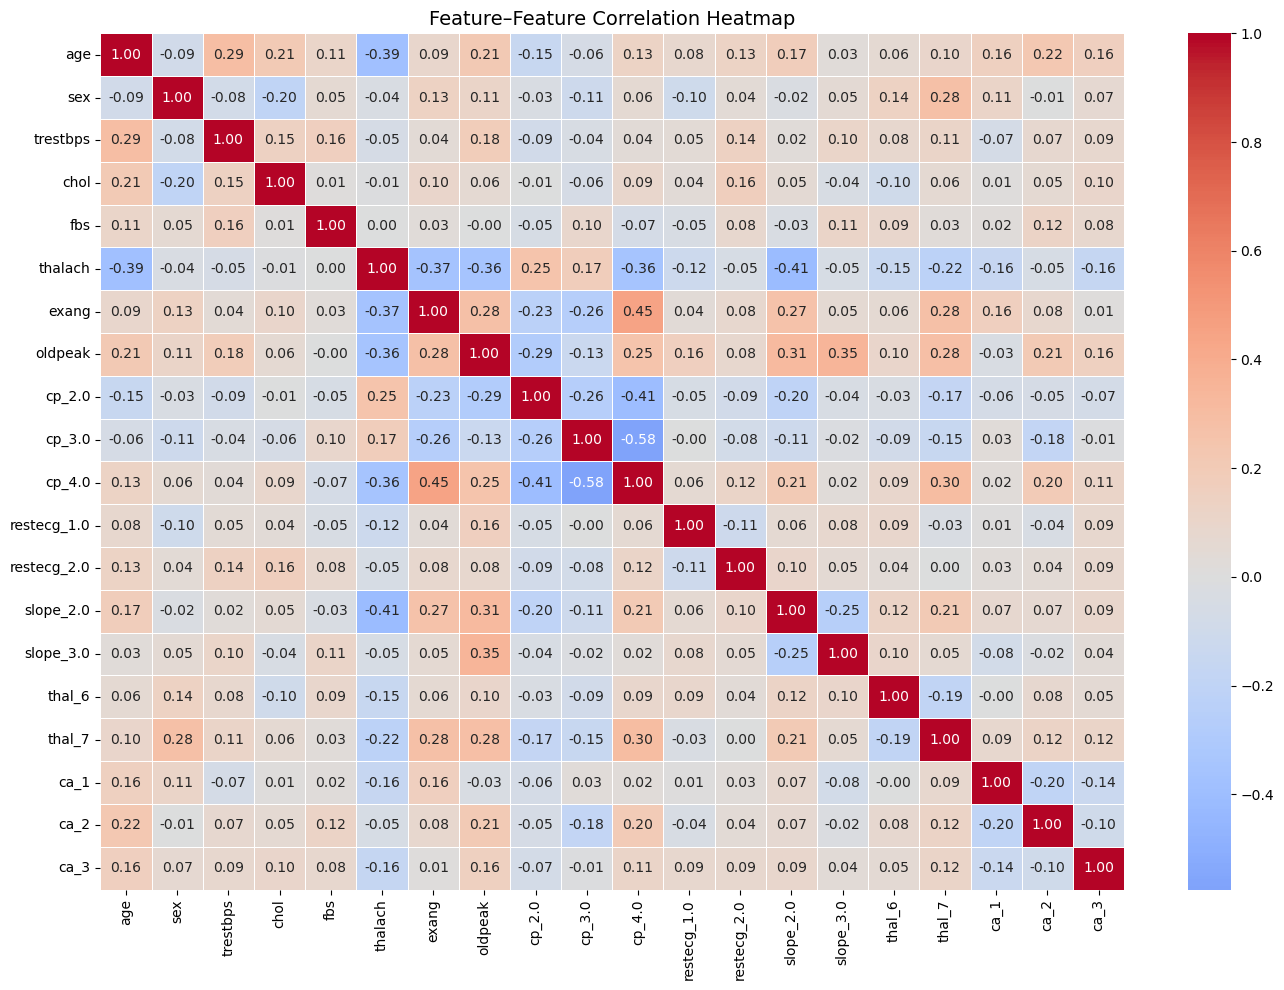

In [7]:
# ================================================================
# METHOD 4: PEARSON CORRELATION
# ================================================================
corr_series = X_work_scaled.corrwith(y_full).abs().sort_values(ascending=False)

corr_df = pd.DataFrame({
    'Feature'    : corr_series.index,
    'Correlation': corr_series.values
}).reset_index(drop=True)

print("=" * 55)
print("📊 METHOD 4: PEARSON CORRELATION WITH TARGET")
print("=" * 55)
print(corr_df.to_string(index=False))

plt.figure(figsize=(10, 7))
colors = ['green' if c >= 0.1 else 'salmon' for c in corr_series.values]
plt.barh(corr_series.index[::-1], corr_series.values[::-1], color=colors[::-1])
plt.axvline(x=0.1, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.1')
plt.title('Pearson Correlation with Target (Green = |corr| ≥ 0.1)', fontsize=13)
plt.xlabel('Absolute Correlation')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(X_work_scaled.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature–Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

---
## Cell 7 — Method 5: Mutual Information

### What is Mutual Information?

Mutual Information measures how much information a feature provides about the target.

Unlike Pearson Correlation, it can detect both:
- Linear relationships
- Non-linear relationships

This makes it useful when a feature affects the target in a more complicated way.

**How it works:**
- Score each feature based on how much knowing that feature helps predict the target
- Higher score = more useful feature

In this notebook, we consider features important if:

`Mutual Information > 0.01`

📊 METHOD 5: MUTUAL INFORMATION SCORES
    Feature  MI_Score
     cp_4.0  0.141271
    oldpeak  0.117429
      exang  0.085138
    thalach  0.082220
     thal_7  0.070360
       chol  0.068331
     cp_3.0  0.043949
  slope_3.0  0.040690
        sex  0.039849
     cp_2.0  0.034955
       ca_1  0.033901
        age  0.031341
restecg_1.0  0.029544
     thal_6  0.024867
  slope_2.0  0.021698
   trestbps  0.017790
       ca_3  0.009261
restecg_2.0  0.004663
        fbs  0.000000
       ca_2  0.000000


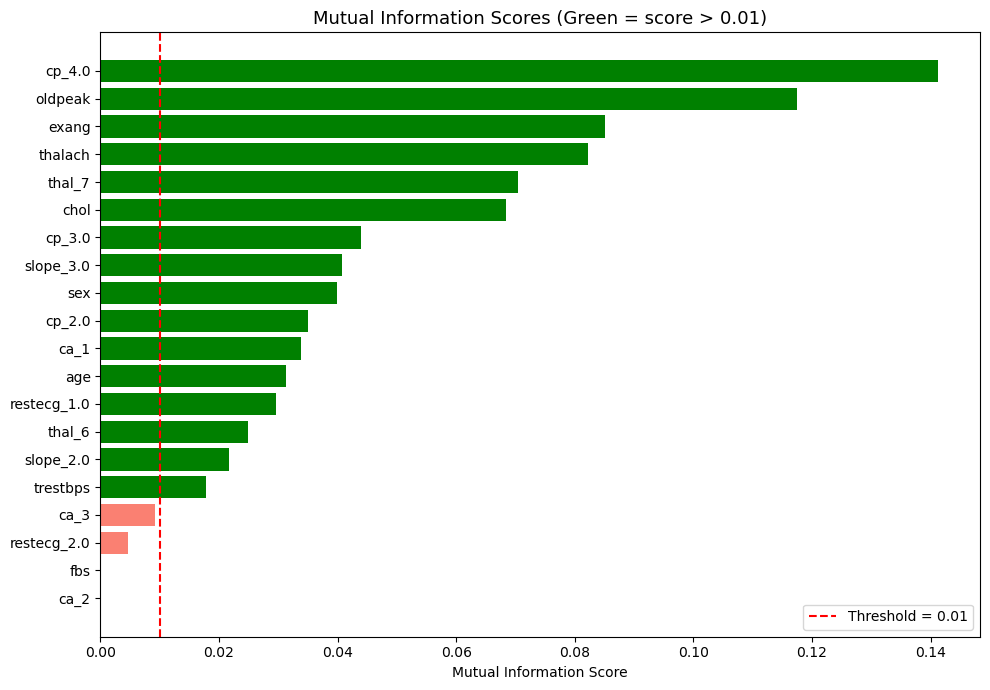

In [8]:
# ================================================================
# METHOD 5: MUTUAL INFORMATION
# ================================================================
mi_scores = mutual_info_classif(X_work_raw, y_full, random_state=42)

mi_df = pd.DataFrame({
    'Feature' : X_work_raw.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

print("=" * 55)
print("📊 METHOD 5: MUTUAL INFORMATION SCORES")
print("=" * 55)
print(mi_df.to_string(index=False))

plt.figure(figsize=(10, 7))
colors = ['green' if s > 0.01 else 'salmon' for s in mi_df['MI_Score']]
plt.barh(mi_df['Feature'][::-1], mi_df['MI_Score'][::-1], color=colors[::-1])
plt.axvline(x=0.01, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.01')
plt.title('Mutual Information Scores (Green = score > 0.01)', fontsize=13)
plt.xlabel('Mutual Information Score')
plt.legend()
plt.tight_layout()
plt.show()

---
## Cell 8 — Method 6: SelectKBest

### What is SelectKBest?

SelectKBest automatically keeps only the top `K` highest-scoring features.

Instead of using all features, we ask the method:

> "Which are the best 10 features?"

In this notebook, we apply SelectKBest twice:
1. Using ANOVA F-scores
2. Using Mutual Information scores

Then we compare the two lists and find the features selected by both methods.

This helps us identify the features that are consistently important.

In [9]:
# ================================================================
# METHOD 6: SelectKBest
# ================================================================
K = 10

skb_anova = SelectKBest(score_func=f_classif, k=K)
skb_anova.fit(X_work_scaled, y_full)
top_k_anova = X_work_scaled.columns[skb_anova.get_support()].tolist()

skb_mi = SelectKBest(score_func=mutual_info_classif, k=K)
skb_mi.fit(X_work_raw, y_full)
top_k_mi = X_work_raw.columns[skb_mi.get_support()].tolist()

common = list(set(top_k_anova) & set(top_k_mi))

print("=" * 55)
print(f"📊 METHOD 6: SelectKBest (K = {K})")
print("=" * 55)
print(f"\n🔹 ANOVA top {K}:\n   {top_k_anova}")
print(f"\n🔹 MI    top {K}:\n   {top_k_mi}")
print(f"\n✅ Selected by BOTH ({len(common)} features):\n   {common}")

📊 METHOD 6: SelectKBest (K = 10)

🔹 ANOVA top 10:
   ['sex', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'slope_2.0', 'thal_7', 'ca_2']

🔹 MI    top 10:
   ['sex', 'chol', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_2.0', 'thal_7']

✅ Selected by BOTH (8 features):
   ['sex', 'cp_2.0', 'thal_7', 'exang', 'thalach', 'oldpeak', 'cp_4.0', 'cp_3.0']


---
## Cell 9 — Combine Results, Vote, and Save Final Features

After applying all filter methods, we combine their results into one summary table.

Each feature receives one vote every time it is selected by a method.

For example:
- Selected by Chi-Square → +1 vote
- Selected by ANOVA → +1 vote
- Selected by Mutual Information → +1 vote

At the end:
- Features with more votes are considered more reliable
- We keep only features selected by at least 4 methods

`Vote Threshold = 4 / 7`

The final selected features are then saved and used to retrain all machine learning models.

📋 FILTER METHODS — FULL SUMMARY
    Feature  Variance_OK  Chi2_Sig  ANOVA_Sig  Corr_OK  MI_OK  SelectK_ANOVA  SelectK_MI  Votes
     cp_4.0         True      True       True     True   True           True        True      7
     thal_7         True      True       True     True   True           True        True      7
    thalach         True      True       True     True   True           True        True      7
      exang         True      True       True     True   True           True        True      7
    oldpeak         True      True       True     True   True           True        True      7
     cp_2.0         True      True       True     True   True           True        True      7
     cp_3.0         True      True       True     True   True           True        True      7
        sex         True      True       True     True   True           True        True      7
  slope_2.0         True      True       True     True   True           True       False      6
       c

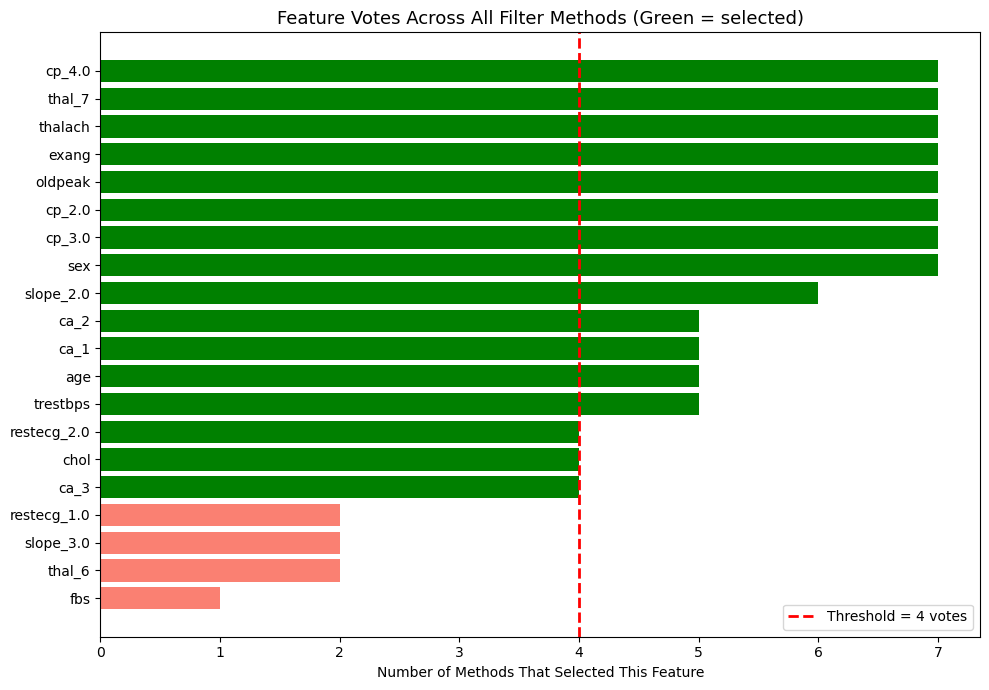


✅ Saved to saved_data/
   filter_selected_features.pkl → 16 features
   X_train_filter.pkl           → shape (262, 16)
   X_test_filter.pkl            → shape (61, 16)

➡️  Next: 07_wrapper_feature_selection.ipynb


In [10]:
# ============================================================
# CELL 9 — Summary, Voting & Save
# ============================================================

summary = pd.DataFrame({'Feature': list(X_work_scaled.columns)})

summary['Variance_OK']   = summary['Feature'].isin(kept_after_variance)
summary['Chi2_Sig']      = summary['Feature'].isin(chi2_df[chi2_df['P_Value']   < 0.05]['Feature'])
summary['ANOVA_Sig']     = summary['Feature'].isin(anova_df[anova_df['P_Value'] < 0.05]['Feature'])
summary['Corr_OK']       = summary['Feature'].isin(corr_df[corr_df['Correlation'] >= 0.1]['Feature'])
summary['MI_OK']         = summary['Feature'].isin(mi_df[mi_df['MI_Score'] > 0.01]['Feature'])
summary['SelectK_ANOVA'] = summary['Feature'].isin(top_k_anova)
summary['SelectK_MI']    = summary['Feature'].isin(top_k_mi)

vote_cols = ['Variance_OK','Chi2_Sig','ANOVA_Sig','Corr_OK','MI_OK','SelectK_ANOVA','SelectK_MI']
summary['Votes'] = summary[vote_cols].sum(axis=1)
summary = summary.sort_values('Votes', ascending=False).reset_index(drop=True)

print("=" * 60)
print("📋 FILTER METHODS — FULL SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))

VOTE_THRESHOLD = 4
final_features = summary[summary['Votes'] >= VOTE_THRESHOLD]['Feature'].tolist()

print("\n" + "=" * 60)
print(f"✅ FINAL SELECTED FEATURES (≥ {VOTE_THRESHOLD}/7 votes): {len(final_features)}")
print("=" * 60)
print(final_features)

# --- Chart ---
plt.figure(figsize=(10, 7))
colors = ['green' if v >= VOTE_THRESHOLD else 'salmon' for v in summary['Votes']]
plt.barh(summary['Feature'][::-1], summary['Votes'][::-1], color=colors[::-1])
plt.axvline(x=VOTE_THRESHOLD, color='red', linestyle='--',
            linewidth=2, label=f'Threshold = {VOTE_THRESHOLD} votes')
plt.title('Feature Votes Across All Filter Methods (Green = selected)', fontsize=13)
plt.xlabel('Number of Methods That Selected This Feature')
plt.legend()
plt.tight_layout()
plt.show()

# --- Save ---
SAVE_DIR = 'saved_data'
os.makedirs(SAVE_DIR, exist_ok=True)

X_train_filter = X_train_scaled[final_features].copy()
X_test_filter  = X_test_scaled[final_features].copy()

joblib.dump(final_features,  f'{SAVE_DIR}/filter_selected_features.pkl')
joblib.dump(X_train_filter,  f'{SAVE_DIR}/X_train_filter.pkl')
joblib.dump(X_test_filter,   f'{SAVE_DIR}/X_test_filter.pkl')

print(f"\n✅ Saved to {SAVE_DIR}/")
print(f"   filter_selected_features.pkl → {len(final_features)} features")
print(f"   X_train_filter.pkl           → shape {X_train_filter.shape}")
print(f"   X_test_filter.pkl            → shape {X_test_filter.shape}")
print(f"\n➡️  Next: 07_wrapper_feature_selection.ipynb")

---
## Cell 10 — Load Final Features and Define Models

> We load the final feature subset selected by the filter methods.

> Then we define all 8 machine learning models that will be retrained using only those selected features.

In [11]:
# ============================================================
# RETRAIN — Load Data & Define All 8 Models
# ============================================================

SAVE_DIR = 'saved_data'
import joblib

# Load filter results from saved_data
final_features   = joblib.load(f'{SAVE_DIR}/filter_selected_features.pkl')
X_train_filter   = joblib.load(f'{SAVE_DIR}/X_train_filter.pkl')
X_test_filter    = joblib.load(f'{SAVE_DIR}/X_test_filter.pkl')

print(f"✅ Filter features loaded: {len(final_features)} features")
print(f"   {final_features}")

from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm            import SVC
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.naive_bayes    import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost                import XGBClassifier
from sklearn.metrics        import f1_score

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(),
    'XGBoost'             : XGBClassifier(eval_metric='logloss', random_state=42),
    'Naive Bayes'         : GaussianNB(),
    'Neural Network (MLP)': MLPClassifier(max_iter=500, random_state=42)
}

print(f"✅ {len(models)} models defined.")

✅ Filter features loaded: 16 features
   ['cp_4.0', 'thal_7', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'sex', 'slope_2.0', 'ca_2', 'ca_1', 'age', 'trestbps', 'restecg_2.0', 'chol', 'ca_3']
✅ 8 models defined.


---
## Cell 11 — Retrain All Models Using Filter-Selected Features

Now that we have a smaller and more useful feature set, we retrain every model.

For each model:
- Train using only the selected features
- Predict on the test set
- Calculate the weighted F1-score

This allows us to see whether feature selection improves model performance.

In [12]:
# ============================================================
# RETRAIN — Train All 8 Models on Filter-Selected Features
# ============================================================

import pandas as pd

# Load y_train and y_test
y_train = joblib.load(f'{SAVE_DIR}/y_train.pkl')
y_test  = joblib.load(f'{SAVE_DIR}/y_test.pkl')
y_train = pd.Series(y_train).reset_index(drop=True)
y_test  = pd.Series(y_test).reset_index(drop=True)

print(f"🔁 Training on {len(final_features)} filter-selected features...\n")

filter_f1_scores = {}

for name, model in models.items():
    model.fit(X_train_filter, y_train)
    y_pred = model.predict(X_test_filter)
    f1 = f1_score(y_test, y_pred, average='weighted')
    filter_f1_scores[name] = round(f1, 4)
    print(f"   {name:<25} F1 = {f1:.4f}")

print("\n✅ Done!")

🔁 Training on 16 filter-selected features...

   Logistic Regression       F1 = 0.8854
   Decision Tree             F1 = 0.7213
   Random Forest             F1 = 0.9017
   SVM                       F1 = 0.8852
   KNN                       F1 = 0.8686
   XGBoost                   F1 = 0.9017
   Naive Bayes               F1 = 0.8690
   Neural Network (MLP)      F1 = 0.8525

✅ Done!


---
## Cell 12 — Compare Baseline vs Filter Feature Selection

In this step, we compare:

- Baseline performance = model trained using all features
- Filter performance = model trained using only the selected features

We calculate the difference in F1-score for every model to see:
- Which models improved
- Which stayed the same
- Which became worse

The comparison chart makes it easy to visualize the effect of feature selection.

📊 F1 SCORE — BASELINE vs FILTER FEATURE SELECTION
               Model  Baseline F1  Filter F1  Difference Improved?
 Logistic Regression            0     0.8854      0.8854     ✅ Yes
       Decision Tree            0     0.7213      0.7213     ✅ Yes
       Random Forest            0     0.9017      0.9017     ✅ Yes
                 SVM            0     0.8852      0.8852     ✅ Yes
                 KNN            0     0.8686      0.8686     ✅ Yes
             XGBoost            0     0.9017      0.9017     ✅ Yes
         Naive Bayes            0     0.8690      0.8690     ✅ Yes
Neural Network (MLP)            0     0.8525      0.8525     ✅ Yes

🏆 Best model after Filter: Random Forest  (F1 = 0.9017)


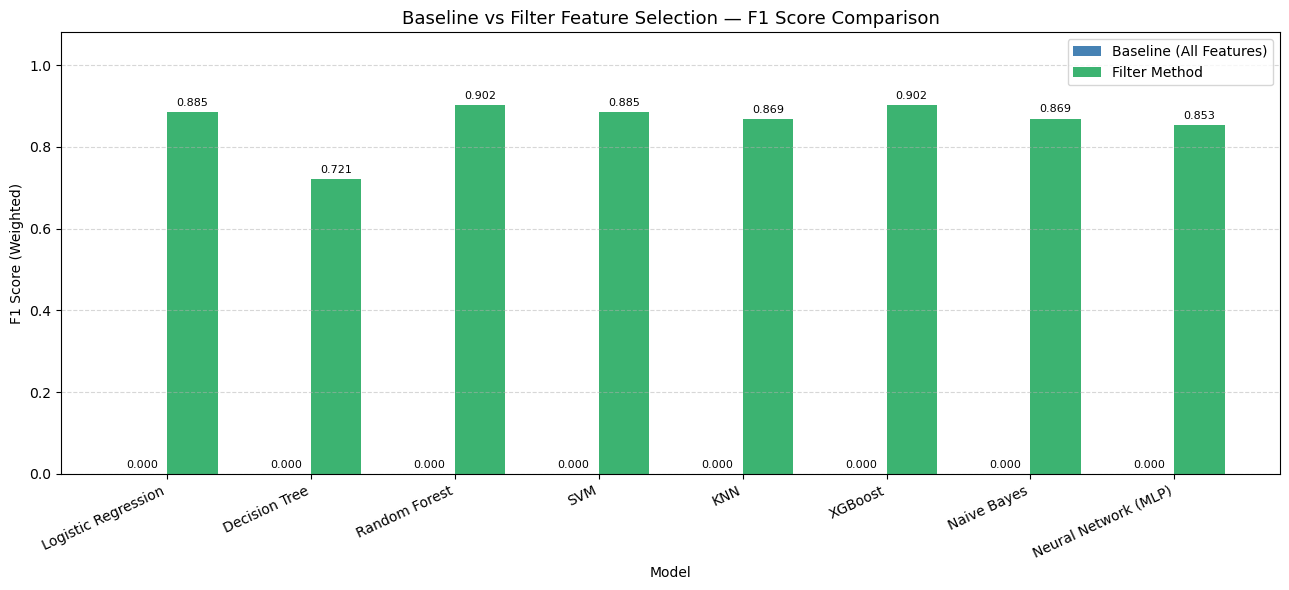

In [13]:
# ============================================================
# RETRAIN — Compare Baseline vs Filter F1 Scores
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

baseline_results = joblib.load(f'{SAVE_DIR}/baseline_results.pkl')

# Extract baseline F1 scores
baseline_f1_scores = {}
for name in models.keys():
    if name in baseline_results:
        res = baseline_results[name]
        if isinstance(res, dict):
            baseline_f1_scores[name] = round(res.get('f1', res.get('F1', 0)), 4)
        else:
            baseline_f1_scores[name] = round(float(res), 4)

# Build comparison table
model_names = list(models.keys())
comparison_df = pd.DataFrame({
    'Model'      : model_names,
    'Baseline F1': [baseline_f1_scores.get(n, 0) for n in model_names],
    'Filter F1'  : [filter_f1_scores.get(n, 0)   for n in model_names],
})

comparison_df['Difference'] = (
    comparison_df['Filter F1'] - comparison_df['Baseline F1']
).round(4)

comparison_df['Improved?'] = comparison_df['Difference'].apply(
    lambda x: '✅ Yes' if x > 0 else ('➡️ Same' if x == 0 else '❌ No'))

print("=" * 65)
print("📊 F1 SCORE — BASELINE vs FILTER FEATURE SELECTION")
print("=" * 65)
print(comparison_df.to_string(index=False))

best = comparison_df.loc[comparison_df['Filter F1'].idxmax()]
print(f"\n🏆 Best model after Filter: {best['Model']}  (F1 = {best['Filter F1']})")

# --- Bar Chart ---
x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, comparison_df['Baseline F1'],
               width, label='Baseline (All Features)', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df['Filter F1'],
               width, label='Filter Method',           color='mediumseagreen')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model')
ax.set_ylabel('F1 Score (Weighted)')
ax.set_title('Baseline vs Filter Feature Selection — F1 Score Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=25, ha='right')
ax.set_ylim(0, 1.08)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Cell 13 — Save Final Results

Finally, we save:
- The new F1-scores after filter feature selection
- The comparison table between Baseline and Filter results

These saved files will be used later in the Wrapper and Embedded feature selection notebooks.

In [14]:
# ============================================================
# RETRAIN — Save Results
# ============================================================

joblib.dump(filter_f1_scores, f'{SAVE_DIR}/filter_retrain_f1.pkl')
comparison_df.to_csv(f'{SAVE_DIR}/filter_retrain_comparison.csv', index=False)

print(f"✅ Saved to {SAVE_DIR}/")
print(f"   filter_retrain_f1.pkl            → F1 scores after filter")
print(f"   filter_retrain_comparison.csv    → full comparison table")
print(f"\n➡️  Next: 07_wrapper_feature_selection.ipynb")

✅ Saved to saved_data/
   filter_retrain_f1.pkl            → F1 scores after filter
   filter_retrain_comparison.csv    → full comparison table

➡️  Next: 07_wrapper_feature_selection.ipynb
